In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

print(mssfp.__version__)

0.0.6


In [2]:
# base model
phi4a = 0, 180
phi4b = 90, 270

# model for T2 map
phi8a = 0, 90, 180, 270
phi8b = 45, 135, 225, 315

# model for T2 map (with 2 phases)
phi8c = 0, 180
phi9d = 45, 90, 135, 225, 270, 315

#cascaded_model ==> 0, 180 -> 90, 270 -> 45, 135, 225, 315

In [3]:
slices = 1
dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=slices, shape=128, ids=[1, 2, 3, 4],
                                        npcs=8, f=500, alpha=np.deg2rad(60), sigma=0.001, data_indices=[(0, 2), (120,180)], 
                                        useRotate=True, useDeform=True)

Generating phantom...
Generating SSFP dataset...
Dataset complete.
Dataset shape: (1, 128, 128, 8)


c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:66: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:92: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)


Selected indices: [0]
Figure size: (16, 2)


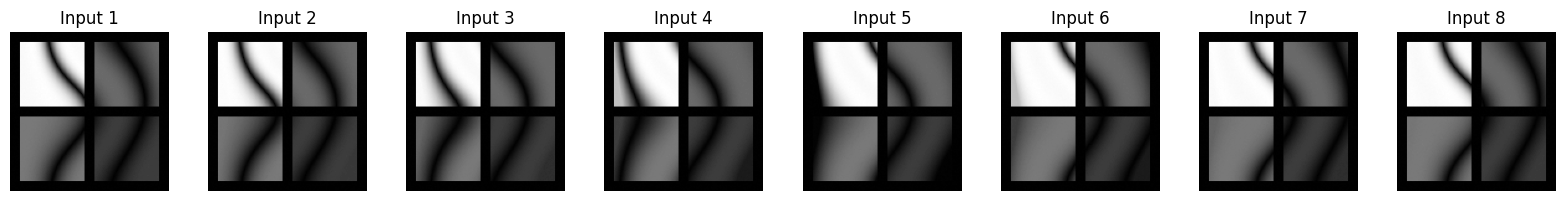

In [4]:
deepssfp.visualize_images(input_images=dataset['M'], num_samples=3)

In [ ]:
mode = 'SyntheticBanding'
ds = deepssfp.dataset.Dataset(mode, input_data=dataset['M'])

Formatting data...
Dataset: mode:SyntheticBanding, size:1 height:128 width:128 cin:8 cout:8 ratio:0.8
dtype: float64, float64
Using same scaler for SyntheticBanding mode


Selected indices: [0]
Figure size: (16, 2)


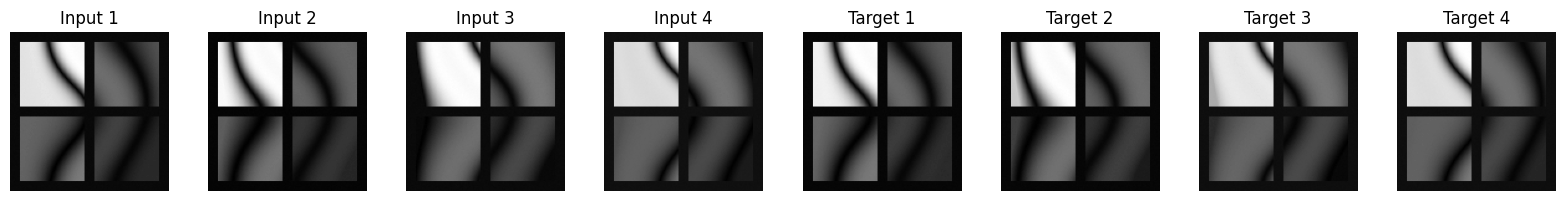

In [7]:
deepssfp.visualize_images(input_images=ds.x_test, target_images=ds.y_test, num_samples=3)